# Energy Demand Forecasting: ARIMA vs. Exponential Smoothing vs. LSTM
## PJMW Hourly Energy Consumption (PJM Interconnection, PJM West Region)

---

## Project Overview

This project forecasts daily energy demand using real-world hourly consumption data (April 2002 - August 2018, ~143,000 records, aggregated to daily averages). The goal is to compare classical statistical forecasting against a deep learning approach and identify which model best supports decisions like utility load balancing, energy trading, and renewable-integration planning.

**Models compared:** ARIMA (manual + auto-tuned), Exponential Smoothing (SES, Holt, Holt-Winters), LSTM

**Result:** The LSTM model cut forecast error roughly in half versus the best classical baseline (RMSE: 729 -> 326 MW, MAPE: 10.7% -> 4.32%), by learning a 60-day sliding-window sequence representation of the demand series.

---

## Pipeline
1. Library Imports & Configuration
2. Dataset Loading & Cleaning
3. Exploratory Data Analysis (EDA)
4. Stationarity Testing & Decomposition
5. Train / Test Split
6. Evaluation Metrics
7. ARIMA Models
8. Exponential Smoothing Models
9. LSTM Model Development
10. Final Model Evaluation & Comparison
11. Key Insights, Limitations, and Real-World Applications


---
## Section 1 – Library Imports & Configuration

We begin by importing all necessary libraries. The project uses:
- **pandas / numpy** for data manipulation
- **matplotlib / seaborn** for visualization
- **statsmodels** for ARIMA and Exponential Smoothing
- **pmdarima** for automatic ARIMA parameter selection
- **scikit-learn** for preprocessing and metrics
- **TensorFlow / Keras** for the LSTM deep learning model


In [1]:
# ── Auto-install missing packages ─────────────────────
import sys
import subprocess
import importlib.util

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "statsmodels": "statsmodels",
    "pmdarima": "pmdarima",
    "scikit-learn": "sklearn",
    "tensorflow": "tensorflow"
}

for package, import_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {package}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# ── Core ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ── Visualization ─────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Statistical / Time Series ─────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

# ── Machine Learning ──────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Deep Learning ─────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── Reproducibility ───────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully.")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   pandas version     : {pd.__version__}")

✅ All libraries imported successfully.
   TensorFlow version : 2.21.0
   pandas version     : 3.0.2


---
## Section 2 – Dataset Loading & Description

### About the Dataset
The **PJMW Hourly Energy Consumption** dataset contains electricity demand data from the PJM West (PJMW) region in the United States, provided by PJM Interconnection.

| Property | Value |
|---|---|
| Source | PJM Interconnection LLC via Kaggle |
| Frequency | Hourly |
| Time Span | 2002-04-01 → 2018-08-03 |
| Records | ~143,200 |
| Target Variable | `PJMW_MW` – Energy Consumption in Megawatts |

> **Important framing note:** The original dataset is **hourly**, but in this project the forecasting task is reformulated as **daily average demand forecasting**. This aggregation reduces high-frequency noise and computational cost, and makes comparison across ARIMA, Exponential Smoothing, and LSTM more manageable for the project scope. As a result, the final forecasts should be interpreted as forecasts of **daily average PJMW demand**, not hourly load. 


---

### Loading, Cleaning Data:

In [2]:
# ── Load raw hourly data ──────────────────────────────
df_raw = pd.read_csv('PJMW_hourly.csv', parse_dates=['Datetime'], index_col='Datetime')
df_raw.sort_index(inplace=True)

# Expected hourly timestamp range
full_hourly_range = pd.date_range(
    start=df_raw.index.min(),
    end=df_raw.index.max(),
    freq='h'
)

missing_timestamps = full_hourly_range.difference(df_raw.index)
duplicate_timestamps = df_raw.index.duplicated().sum()

print("=== Raw Hourly Dataset ===")
print(f"Shape                : {df_raw.shape}")
print(f"Columns              : {list(df_raw.columns)}")
print(f"Date range           : {df_raw.index.min()} → {df_raw.index.max()}")
print(f"Inferred frequency   : {df_raw.index.inferred_freq}")
print(f"Missing values       : {df_raw.isnull().sum().sum()}")
print(f"Duplicate timestamps : {duplicate_timestamps}")
print(f"Missing timestamps   : {len(missing_timestamps)}")
print()

print("=== Data Types ===")
print(df_raw.dtypes)
print()

print("=== Missing Values by Column ===")
print(df_raw.isnull().sum())
print()

if len(missing_timestamps) > 0:
    print("First 5 missing timestamps:")
    print(missing_timestamps[:5])
    print()

if duplicate_timestamps > 0:
    print("First 5 duplicate timestamps:")
    print(df_raw.index[df_raw.index.duplicated()].unique()[:5])
    print()

print("=== First 5 Rows ===")
print(df_raw.head(5))

=== Raw Hourly Dataset ===
Shape                : (143206, 1)
Columns              : ['PJMW_MW']
Date range           : 2002-04-01 01:00:00 → 2018-08-03 00:00:00
Inferred frequency   : None
Missing values       : 0
Duplicate timestamps : 4
Missing timestamps   : 30

=== Data Types ===
PJMW_MW    float64
dtype: object

=== Missing Values by Column ===
PJMW_MW    0
dtype: int64

First 5 missing timestamps:
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00'],
              dtype='datetime64[us]', freq=None)

First 5 duplicate timestamps:
DatetimeIndex(['2014-11-02 02:00:00', '2015-11-01 02:00:00',
               '2016-11-06 02:00:00', '2017-11-05 02:00:00'],
              dtype='datetime64[us]', name='Datetime', freq=None)

=== First 5 Rows ===
                     PJMW_MW
Datetime                    
2002-04-01 01:00:00   4374.0
2002-04-01 02:00:00   4306.0
2002-04-01 03:00:00   43

In [3]:
# ── Clean hourly time series data (in-place) ─────────────────────────────
print("=== BEFORE CLEANING ===")
print(f"Shape                : {df_raw.shape}")
print(f"Missing values       : {df_raw.isnull().sum().sum()}")
print(f"Duplicate timestamps : {df_raw.index.duplicated().sum()}")

full_range_before = pd.date_range(df_raw.index.min(), df_raw.index.max(), freq='h')
missing_before = len(full_range_before.difference(df_raw.index))
print(f"Missing timestamps   : {missing_before}")
print()

# 1. Handle duplicate timestamps (average duplicates)
df_raw = df_raw.groupby(df_raw.index).mean() #Group duplicates + take the avg + Keeps only one row per 

# 2. Create full hourly index
full_range = pd.date_range(
    start=df_raw.index.min(),
    end=df_raw.index.max(),
    freq='h'
)

# 3. Reindex to include missing timestamps
df_raw = df_raw.reindex(full_range)

# 4. Fill missing values using time interpolation
# Missing values were filled using time-based interpolation, which estimates values by following the trend between surrounding timestamps.
df_raw['PJMW_MW'] = df_raw['PJMW_MW'].interpolate(method='time')

# 5. Restore index name
df_raw.index.name = 'Datetime'

# ── AFTER CLEANING CHECK ─────────────────────────────
print("=== AFTER CLEANING ===")
print(f"Shape                : {df_raw.shape}")
print(f"Missing values       : {df_raw.isnull().sum().sum()}")
print(f"Duplicate timestamps : {df_raw.index.duplicated().sum()}")

full_range_after = pd.date_range(df_raw.index.min(), df_raw.index.max(), freq='h')
missing_after = len(full_range_after.difference(df_raw.index))
print(f"Missing timestamps   : {missing_after}")

print(f"Inferred frequency   : {df_raw.index.inferred_freq}")
print()
print(df_raw.head(5))

=== BEFORE CLEANING ===
Shape                : (143206, 1)
Missing values       : 0
Duplicate timestamps : 4
Missing timestamps   : 30

=== AFTER CLEANING ===
Shape                : (143232, 1)
Missing values       : 0
Duplicate timestamps : 0
Missing timestamps   : 0
Inferred frequency   : h

                     PJMW_MW
Datetime                    
2002-04-01 01:00:00   4374.0
2002-04-01 02:00:00   4306.0
2002-04-01 03:00:00   4322.0
2002-04-01 04:00:00   4359.0
2002-04-01 05:00:00   4436.0


In [4]:
# ── Resample to daily averages ───────────────────────
df = df_raw.resample('D').mean()
df.columns = ['PJMW_MW']

print("=== Daily Resampled Dataset ===")
print(f"Shape      : {df.shape}")
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Missing    : {df.isnull().sum().values[0]}")
print("===============================")
print(df.head(5))
print("===============================")
print(df.describe().round(2))


=== Daily Resampled Dataset ===
Shape      : (5969, 1)
Date range : 2002-04-01 → 2018-08-03
Missing    : 0
                PJMW_MW
Datetime               
2002-04-01  5271.173913
2002-04-02  5310.416667
2002-04-03  5325.916667
2002-04-04  5670.791667
2002-04-05  5686.125000
       PJMW_MW
count  5969.00
mean   5602.19
std     737.79
min    3018.04
25%    5043.88
50%    5522.46
75%    6085.75
max    8794.58


---
## Section 3 – Exploratory Data Analysis (EDA)

We examine:
- overall trend and yearly seasonality using a smoothed time series.
- weekly (weekday vs weekend) and monthly seasonal patterns.
- yearly patterns across different years.


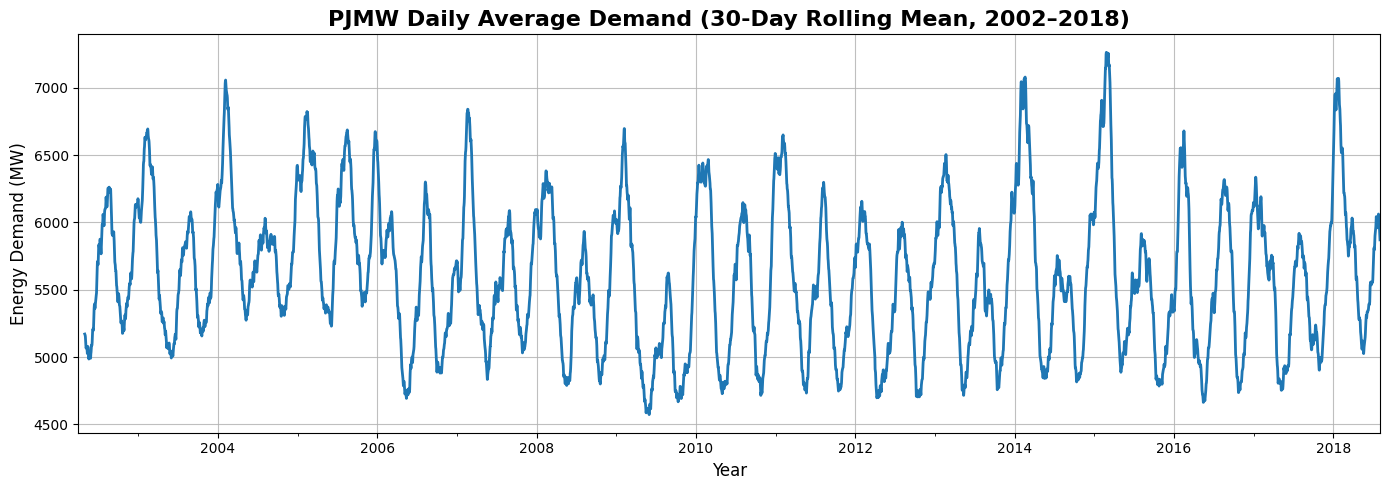

Observation: The smoothed series highlights a strong recurring annual pattern, with repeated peaks and dips across years.


In [5]:
# ── 3.1 Full time series plot (30-day rolling mean) ───────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Smooth with 30-day rolling average for clearer visualization
df['PJMW_MW'].rolling(window=30).mean().plot(
    ax=ax,
    linewidth=2
)

ax.set_title('PJMW Daily Average Demand (30-Day Rolling Mean, 2002–2018)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Energy Demand (MW)', fontsize=12)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

print('Observation: The smoothed series highlights a strong recurring annual pattern, with repeated peaks and dips across years.')

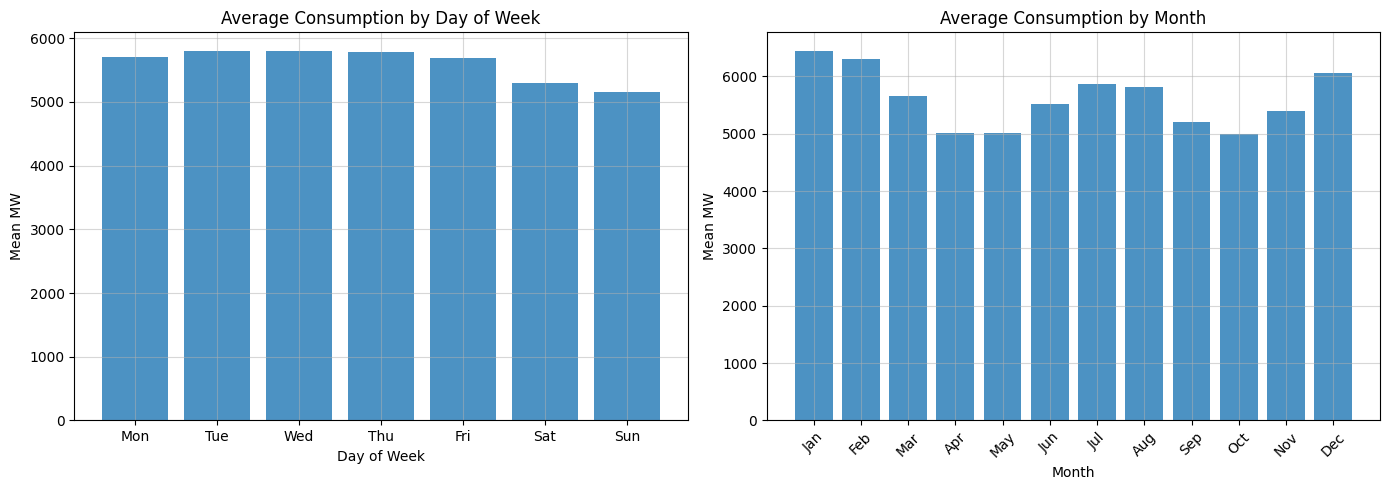

Consumption drops on weekends (Saturday and Sunday), indicating a weekly seasonal pattern.
There is also a clear annual pattern, with higher demand in winter and summer and lower demand in spring and fall.


In [6]:
# ── 3.2 Energy demand at the daily level shows both weekly (day-of-week) and yearly seasonal structure.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week profile
weekly = df.groupby(df.index.dayofweek)["PJMW_MW"].mean()
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

axes[0].bar(range(7), weekly.values, alpha=0.8)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Mean MW")
axes[0].set_title("Average Consumption by Day of Week")
axes[0].grid(True, alpha=0.5)

# Monthly profile
monthly = df.groupby(df.index.month)["PJMW_MW"].mean()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

axes[1].bar(range(1, 13), monthly.values, alpha=0.8)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean MW")
axes[1].set_title("Average Consumption by Month")
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

print("Consumption drops on weekends (Saturday and Sunday), indicating a weekly seasonal pattern.")
print("There is also a clear annual pattern, with higher demand in winter and summer and lower demand in spring and fall.")

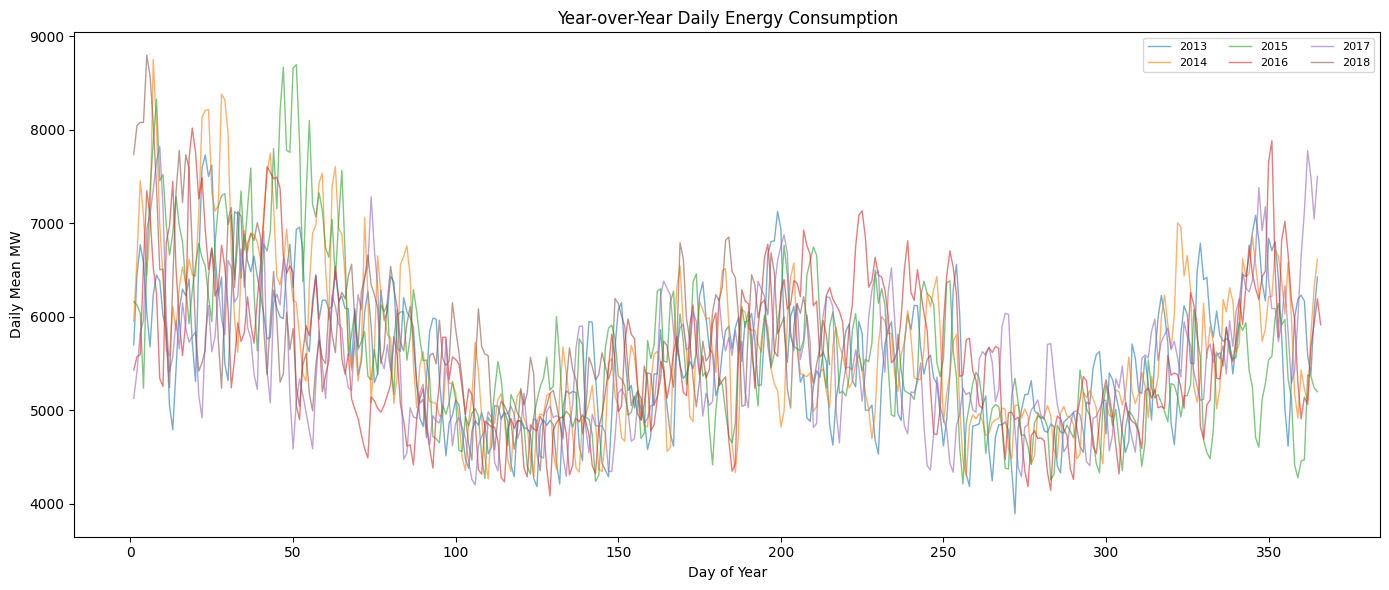

The annual pattern is consistent across years — a strong signal for seasonal models.


In [7]:
# ── 3.3 Year-over-Year Daily Energy Consumption Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Daily average (in case your data isn't already daily)
daily_avg = df['PJMW_MW'].resample("D").mean()

for year in range(2013, 2019):
    year_data = daily_avg.loc[str(year)]
    
    ax.plot(
        year_data.index.dayofyear,
        year_data.values,
        alpha=0.6,
        linewidth=1,
        label=str(year)
    )

ax.set_xlabel("Day of Year")
ax.set_ylabel("Daily Mean MW")
ax.set_title("Year-over-Year Daily Energy Consumption")
ax.legend(ncol=3, fontsize=8)  # cleaner legend
plt.tight_layout()
plt.show()
print("The annual pattern is consistent across years — a strong signal for seasonal models.")

---
## Section 4 – Stationarity Testing & Seasonal Decomposition

### 4.1 Stationarity
A time series is **stationary** when its statistical properties, such as mean, variance, and autocorrelation structure, remain stable over time. Many forecasting models, especially ARIMA, work best when the series is at least approximately stationary.

We begin with the **Augmented Dickey-Fuller (ADF)** test:
- **H₀:** the series has a unit root (is non-stationary)
- Reject **H₀** if **p < 0.05**

However, the ADF test alone is **not sufficient** to determine the final differencing order. In this project, differencing decisions are based on a combination of:
1. **ADF test results**
2. **ACF/PACF behavior**
3. **Empirical model performance**

So, the ADF test is treated as one input into ARIMA model selection, not the only rule.

### 4.2 Decomposition
We also decompose the daily series into **Trend + Seasonality + Residual** components using `seasonal_decompose`.
Because the EDA suggests both **weekly** and **yearly** seasonality, the decomposition below focuses mainly on the **annual seasonal cycle** (`period=365`), while weekly effects are examined separately in the EDA plots.


In [8]:
def adf_test(series, name=""):
    result = adfuller(series.dropna(), autolag="AIC")
    status = "Reject H₀ (no unit root evidence)" if result[1] < 0.05 else "Fail to reject H₀"
    print(f"{name:25s} | ADF stat: {result[0]:8.3f} | p-value: {result[1]:.4f} | {status}")
    return result[1]

p_original = adf_test(df['PJMW_MW'], "Original")
p_diff1 = adf_test(df['PJMW_MW'].diff(), "1st difference")
p_diff7 = adf_test(df['PJMW_MW'].diff(7), "Weekly diff lag=7")
p_diff7_1 = adf_test(df['PJMW_MW'].diff(7).diff(), "Weekly + 1st diff")

print(
    "\nInterpretation:\n"
    "The ADF test shows the series is already stationary."
    "\nHowever, because there is still strong seasonality, we may still apply differencing for ARIMA, and the final choice will depend on ACF/PACF patterns and model performance."
)

Original                  | ADF stat:   -7.265 | p-value: 0.0000 | Reject H₀ (no unit root evidence)
1st difference            | ADF stat:  -14.397 | p-value: 0.0000 | Reject H₀ (no unit root evidence)
Weekly diff lag=7         | ADF stat:  -13.975 | p-value: 0.0000 | Reject H₀ (no unit root evidence)
Weekly + 1st diff         | ADF stat:  -26.136 | p-value: 0.0000 | Reject H₀ (no unit root evidence)

Interpretation:
The ADF test shows the series is already stationary.
However, because there is still strong seasonality, we may still apply differencing for ARIMA, and the final choice will depend on ACF/PACF patterns and model performance.


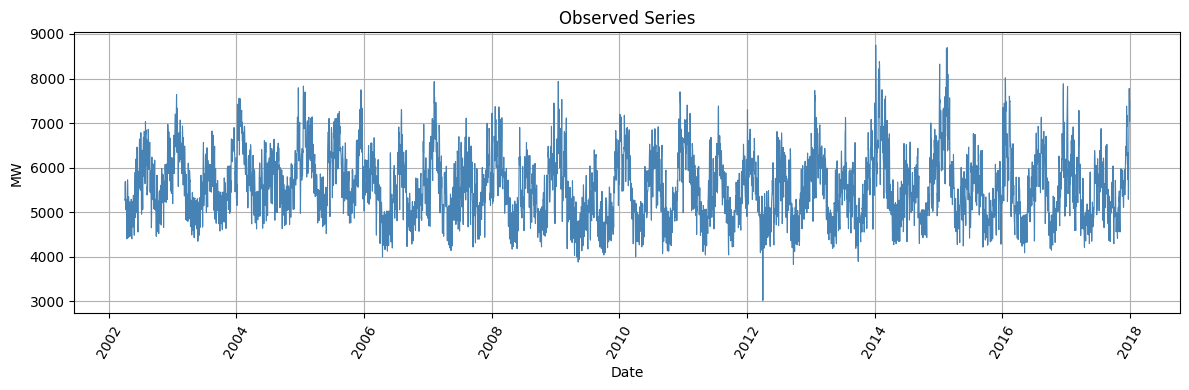

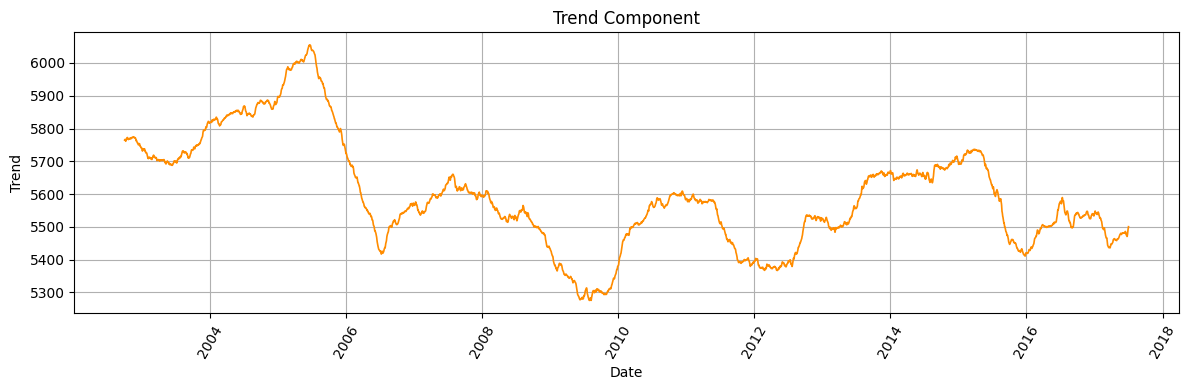

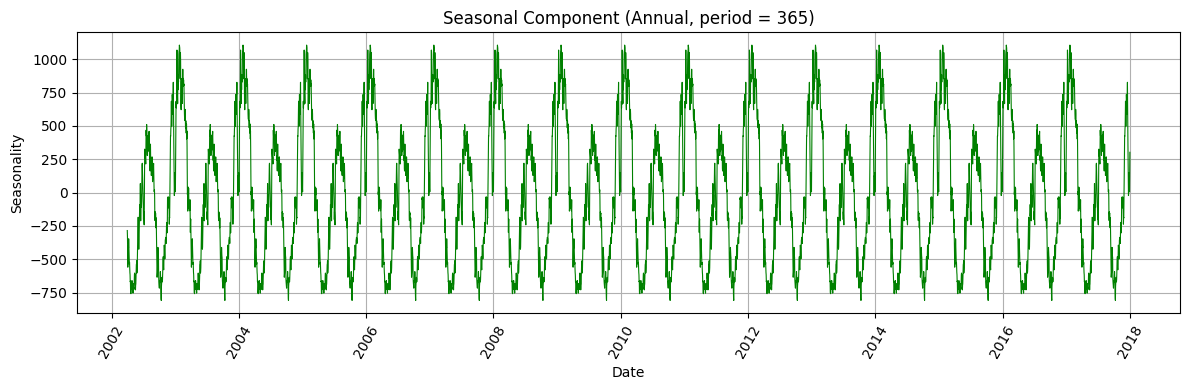

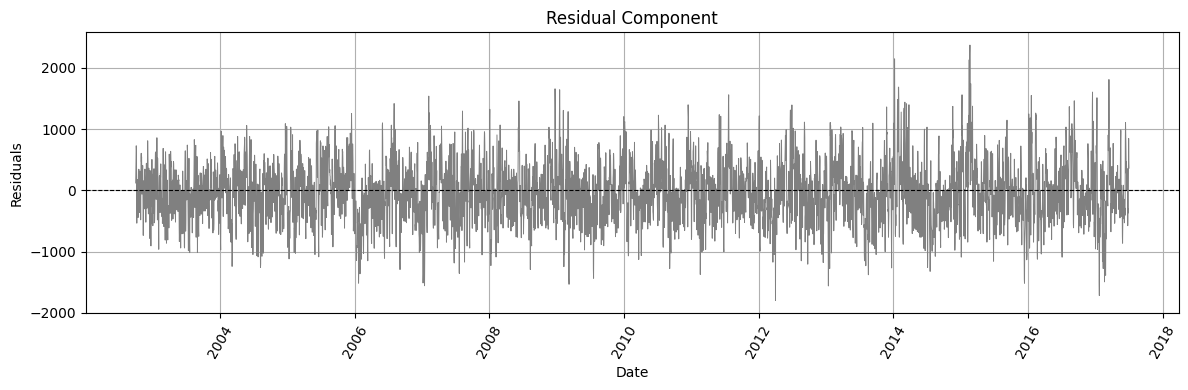

The decomposition highlights a clear annual seasonal component and a changing long-term trend.
 This supports the use of models that can represent level, trend, and seasonality.
 Because standard Holt-Winters can capture only one seasonal cycle at a time, weekly and yearly seasonal periods will later be tested separately.


In [12]:
# ── 4.3 Seasonal decomposition (annual seasonality focus) ─────────────────
subset = df['PJMW_MW']['2002':'2017']
decomp = seasonal_decompose(subset, model='additive', period=365)

# ── Observed ─────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(decomp.observed, color='steelblue', linewidth=0.8)
plt.title('Observed Series')
plt.xlabel('Date')
plt.ylabel('MW')
plt.grid(True)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

# ── Trend ────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(decomp.trend, color='darkorange', linewidth=1.2)
plt.title('Trend Component')
plt.xlabel('Date')
plt.ylabel('Trend')
plt.grid(True)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()
print('')

# ── Seasonal ─────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(decomp.seasonal, color='green', linewidth=0.8)
plt.title('Seasonal Component (Annual, period = 365)')
plt.xlabel('Date')
plt.ylabel('Seasonality')
plt.grid(True)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()
print('')

# ── Residual ─────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(decomp.resid, color='gray', linewidth=0.7)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Residual Component')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(True)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

print(
    'The decomposition highlights a clear annual seasonal component and a changing long-term trend.\n '
    'This supports the use of models that can represent level, trend, and seasonality.\n '
    'Because standard Holt-Winters can capture only one seasonal cycle at a time, weekly and yearly seasonal periods will later be tested separately.'
)

---
## Section 5 – Train / Test Split

We use the last **365 days (1 year)** as the test set and everything before as training data. 

| Split | Period | Size |
|---|---|---|
| Training | 2002-04-01 → 2017-08-03 | ~5,604 days |
| Testing | 2017-08-04 → 2018-08-03 | 365 days |


Training set : 2002-04-01 → 2017-08-03  (5,604 days)
Test set     : 2017-08-04  → 2018-08-03  (365 days)


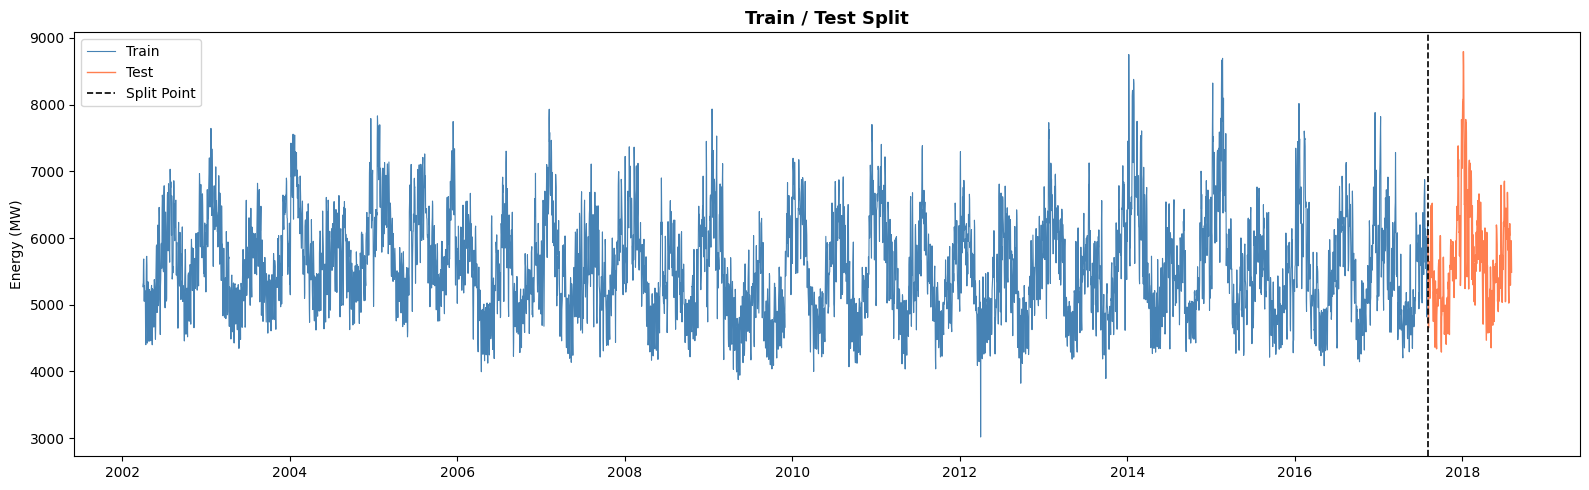

In [13]:
# ── Train/Test split (last 365 days as test) ─────────
series = df['PJMW_MW'].copy()

TEST_SIZE = 365
train = series.iloc[:-TEST_SIZE]
test  = series.iloc[-TEST_SIZE:]

print(f"Training set : {train.index[0].date()} → {train.index[-1].date()}  ({len(train):,} days)")
print(f"Test set     : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test):,} days)")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train.index, train, color='steelblue', linewidth=0.8, label='Train')
ax.plot(test.index,  test,  color='coral',     linewidth=1.0, label='Test')
ax.axvline(test.index[0], color='black', linestyle='--', linewidth=1.2, label='Split Point')
ax.set_title('Train / Test Split', fontweight='bold', fontsize=13)
ax.set_ylabel('Energy (MW)')
ax.legend()
plt.tight_layout()
plt.show()


---
## Section 6 – Evaluation Metrics

We define all metrics upfront so every model is evaluated consistently.

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | mean(|actual − forecast|) | Average absolute error in MW |
| **MSE** | mean((actual − forecast)²) | Penalizes large errors heavily |
| **RMSE** | √MSE | Same units as MW; directly interpretable |
| **MAPE** | mean(|actual − forecast| / actual) × 100 | Percentage error; scale-independent |


In [14]:
# Method to compute any model metrics later 
def compute_metrics(actual, predicted, model_name='Model'):
    mae  = mean_absolute_error(actual, predicted)
    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{'─'*45}")
    print(f"  {model_name} Performance")
    print(f"{'─'*45}")
    print(f"  MAE  : {mae:>10.2f} MW")
    print(f"  MSE  : {mse:>10.2f} MW²")
    print(f"  RMSE : {rmse:>10.2f} MW")
    print(f"  MAPE : {mape:>10.2f} %")
    return {'Model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

results = []   # collect all model results here
print("✅ Metrics function ready.")


✅ Metrics function ready.


---
## Section 7 – Model A: ARIMA (AutoRegressive Integrated Moving Average)

### Background
ARIMA(p, d, q) models capture:
- **p** (AR order): dependence on past values
- **d** (Integration): differencing needed to achieve stationarity
- **q** (MA order): dependence on past forecast errors


### 7.1 ACF and PACF plots for baseline ARIMA identification

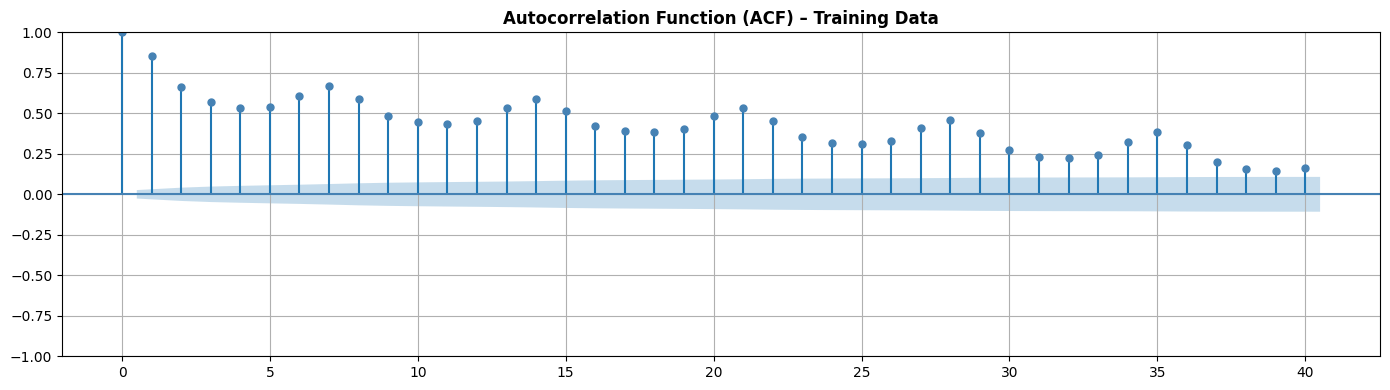

ACF shows slow decay, which suggests that differencing may still be useful for ARIMA. d = 1
There is no strong sharp cutoff in the ACF, so q = 0


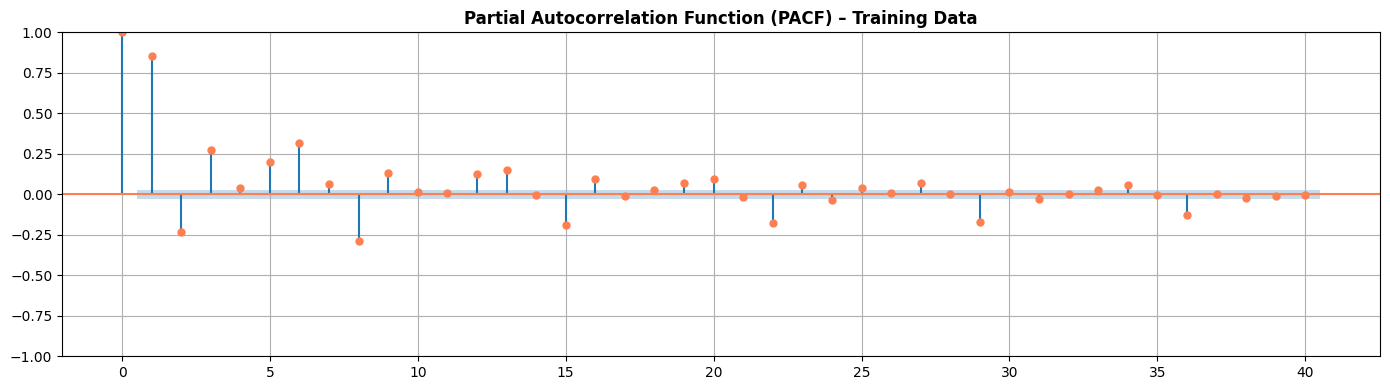

In [15]:
# ── 7.1 ACF and PACF plots for baseline ARIMA identification ─────────────
# is handled more directly in Holt-Winters and later LSTM.

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(train.dropna(), lags=40, ax=ax, color='steelblue')
ax.set_title('Autocorrelation Function (ACF) – Training Data', fontweight='bold')
ax.grid(True)
plt.tight_layout()
plt.show()

print('ACF shows slow decay, which suggests that differencing may still be useful for ARIMA. d = 1')
print('There is no strong sharp cutoff in the ACF, so q = 0')

fig, ax = plt.subplots(figsize=(14, 4))
plot_pacf(train.dropna(), lags=40, ax=ax, color='coral', method='ywm')
ax.set_title('Partial Autocorrelation Function (PACF) – Training Data', fontweight='bold')
ax.grid(True)
plt.tight_layout()
plt.show()


**PACF** shows a strong spike at lag 1 and then weakens, so p = 1
Therefore, ARIMA(1,1,0) is used as the manually selected baseline model Based on ACF and PACF plots

---

### 7.2 Manual ARIMA Training

                               SARIMAX Results                                
Dep. Variable:                PJMW_MW   No. Observations:                 5604
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -41453.976
Date:                Sat, 27 Jun 2026   AIC                          82911.952
Time:                        21:52:30   BIC                          82925.214
Sample:                    04-01-2002   HQIC                         82916.574
                         - 08-03-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1437      0.013     10.754      0.000       0.118       0.170
sigma2      1.563e+05   2478.818     63.043      0.000    1.51e+05    1.61e+05
Ljung-Box (L1) (Q):                  14.51   Jarque-

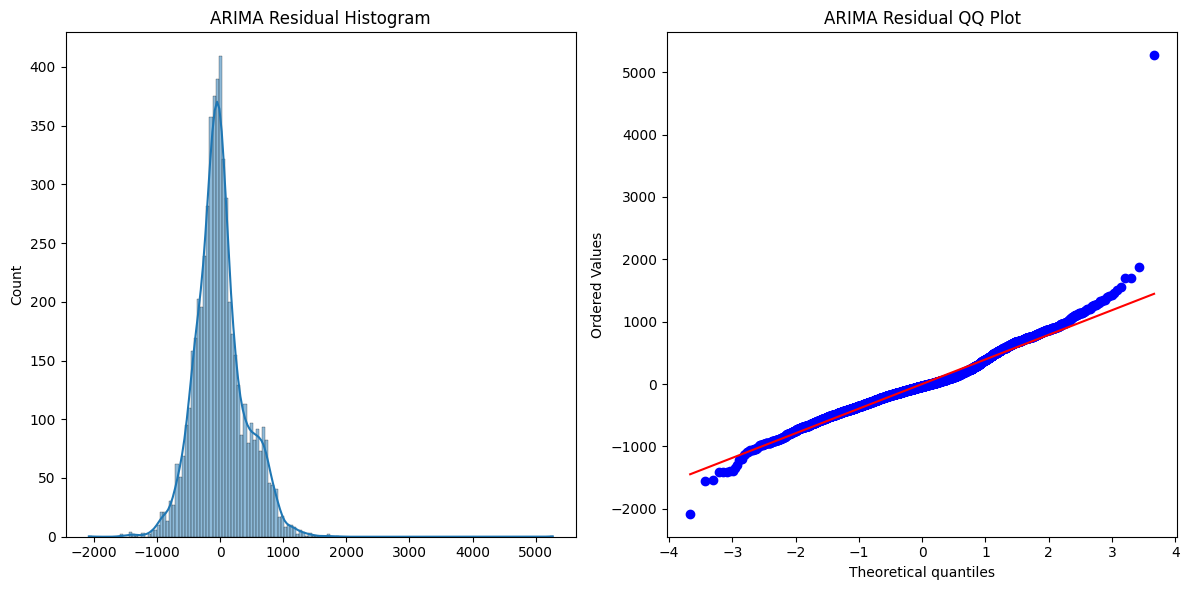


Residual diagnostics summary:
Ljung-Box test p-value (lag 10): 0.0000
Jarque-Bera test p-value       : 0.0000
- Ljung-Box indicates remaining autocorrelation in the residuals.
- Jarque-Bera indicates residuals are not normally distributed.

Conclusion: the manual ARIMA model is useful as a required baseline, but if residual autocorrelation remains, it does not fully capture the structure of the series.


In [16]:
# ── 7.2 Fit manual ARIMA baseline and evaluate residual diagnostics ───────
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# Manual ARIMA selected from ACF/PACF as a required baseline (p=1, d=1, q=0)
arima_model = ARIMA(train, order=(1, 1, 0))
arima_fit = arima_model.fit()

print(arima_fit.summary())

# Residuals
residuals = arima_fit.resid.dropna()

# Plot residual diagnostics
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('ARIMA Residual Histogram')

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('ARIMA Residual QQ Plot')

plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
lb_df = acorr_ljungbox(residuals, lags=[10], return_df=True)
lb_pvalue = lb_df['lb_pvalue'].iloc[0]

# Jarque-Bera test for residual normality
jb_stat, jb_pvalue = stats.jarque_bera(residuals)

print('\nResidual diagnostics summary:')
print(f'Ljung-Box test p-value (lag 10): {lb_pvalue:.4f}')
print(f'Jarque-Bera test p-value       : {jb_pvalue:.4f}')

if lb_pvalue < 0.05:
    print('- Ljung-Box indicates remaining autocorrelation in the residuals.')
else:
    print('- Ljung-Box does not indicate significant residual autocorrelation.')

if jb_pvalue < 0.05:
    print('- Jarque-Bera indicates residuals are not normally distributed.')
else:
    print('- Jarque-Bera does not reject normality of residuals.')

print(
    '\nConclusion: the manual ARIMA model is useful as a required baseline, '\
    'but if residual autocorrelation remains, it does not fully capture the structure of the series.'
)

### 7.3 Manual ARIMA Forecast Evaluation

─────────────────────────────────────────────
  ARIMA(1,1,0) Performance
─────────────────────────────────────────────
  MAE  :     774.66 MW
  MSE  :  842267.77 MW²
  RMSE :     917.75 MW
  MAPE :      14.36 %


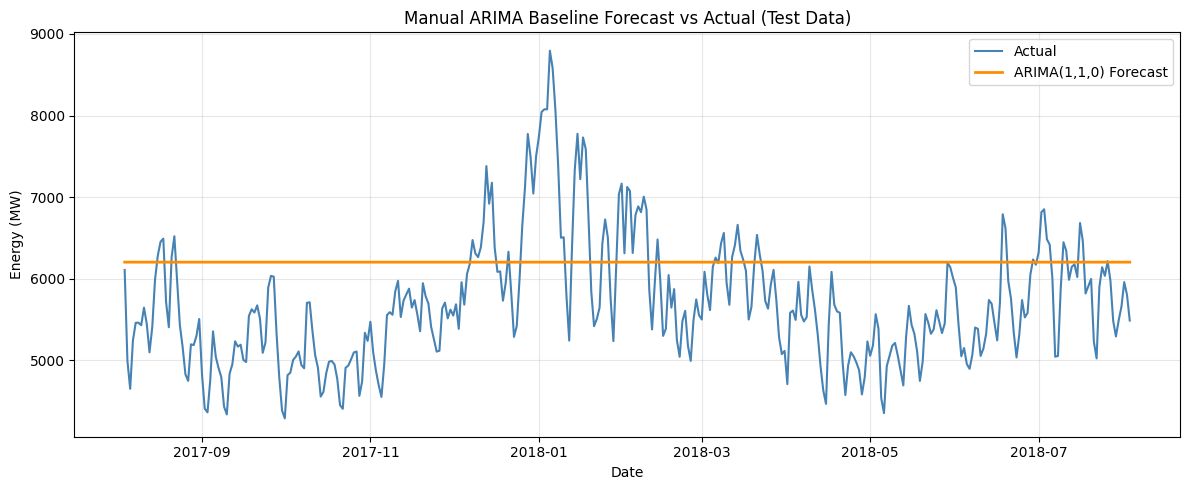

In [17]:
# ── 7.3 Forecast with manual ARIMA baseline and evaluate ─────────────────
# Forecast same number of steps as test data length
n_test = len(test)
arima_forecast = arima_fit.forecast(steps=n_test)

# Align forecast index with test index
arima_forecast = pd.Series(arima_forecast.values, index=test.index)

# Actual values
actual = test.dropna()

# Align forecast with actual after dropna
arima_forecast = arima_forecast.loc[actual.index]

# Evaluation
metrics_arima = compute_metrics(actual, arima_forecast, model_name='ARIMA(1,1,0)')
res_arima = metrics_arima

# Plot forecast vs actual
plt.figure(figsize=(12, 5))
plt.plot(actual.index, actual, label='Actual', linewidth=1.5, color='steelblue')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA(1,1,0) Forecast', linewidth=2, color='darkorange')
plt.title('Manual ARIMA Baseline Forecast vs Actual (Test Data)')
plt.xlabel('Date')
plt.ylabel('Energy (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Auto-ARIMA Selection + Training + Evaluation

Running auto_arima — this may take 1–2 minutes...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=83028.907, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=82913.952, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=82742.550, Time=0.77 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=83026.908, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=82564.901, Time=1.39 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=81601.091, Time=2.50 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=82168.045, Time=0.46 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=81577.751, Time=3.60 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=82118.604, Time=0.35 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=81404.020, Time=3.20 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=81790.063, Time=0.52 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=81519.580, Time=4.85 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=81518.264, Time=3.28 sec
 ARIMA(4,1,1)(0,0,0)[0]             

,Model,MAE,MSE,RMSE,MAPE
0,"ARIMA(1,1,0)",774.661650,842267.772800,917.751477,14.364378
1,"Auto-ARIMA(4, 1, 1)",604.322079,593406.554984,770.328862,10.684769



Auto-ARIMA(4, 1, 1) performs better than manual ARIMA(1,1,0) based on RMSE.

Note: non-seasonal ARIMA is retained here as a baseline model. Seasonal structure is expected to be handled more effectively by Holt-Winters and later by LSTM.


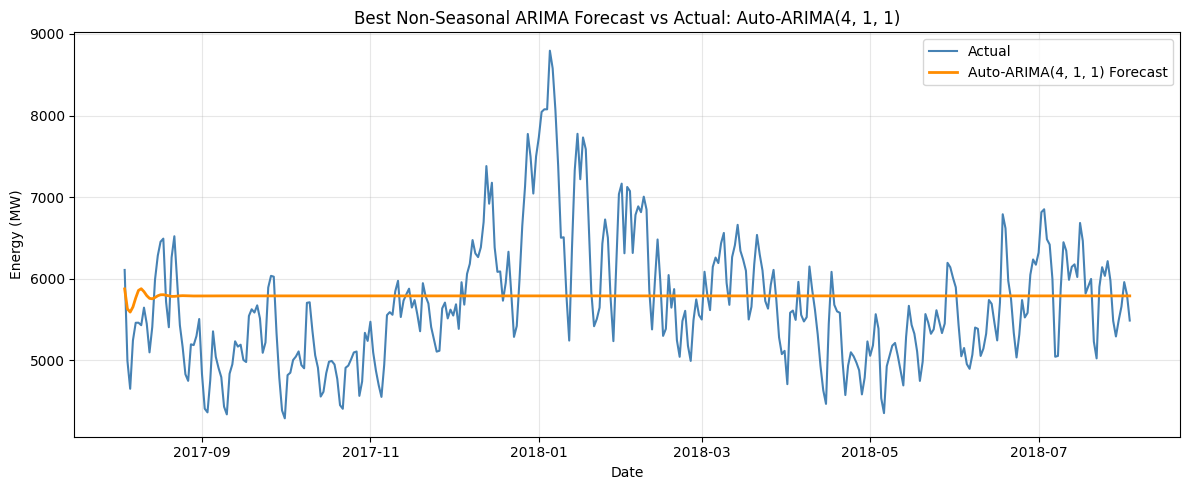

In [18]:
# ── 7.4 Auto-ARIMA search for improved non-seasonal ARIMA baseline ───────
# Auto-ARIMA is included to improve parameter selection.

print('Running auto_arima — this may take 1–2 minutes...')

auto_model = pm.auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=4, max_q=4,
    max_d=2,
    seasonal=False,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print('\nAuto-ARIMA model summary:')
print(auto_model.summary())

best_order = auto_model.order
print(f'\nBest Auto-ARIMA order selected: {best_order}')

auto_arima_model = ARIMA(train, order=best_order)
auto_arima_fit = auto_arima_model.fit()

auto_arima_forecast = auto_arima_fit.forecast(steps=len(test))
auto_arima_forecast = pd.Series(auto_arima_forecast.values, index=test.index)
auto_arima_forecast = auto_arima_forecast.loc[actual.index]

metrics_auto_arima = compute_metrics(
    actual,
    auto_arima_forecast,
    model_name=f'Auto-ARIMA{best_order}'
)
results.append(metrics_auto_arima)
res_auto_arima = metrics_auto_arima

comparison_arima = pd.DataFrame([
    metrics_arima,
    metrics_auto_arima
])

print('\nManual ARIMA vs Auto-ARIMA Accuracy Comparison:')
display(comparison_arima)

if metrics_auto_arima['RMSE'] < metrics_arima['RMSE']:
    print(f"\nAuto-ARIMA{best_order} performs better than manual ARIMA(1,1,0) based on RMSE.")
    best_arima_forecast = auto_arima_forecast
    best_arima_metrics = metrics_auto_arima
    best_arima_name = f'Auto-ARIMA{best_order}'
else:
    print('\nManual ARIMA(1,1,0) performs better than Auto-ARIMA based on RMSE.')
    best_arima_forecast = arima_forecast
    best_arima_metrics = metrics_arima
    best_arima_name = 'ARIMA(1,1,0)'

print(
    '\nNote: non-seasonal ARIMA is retained here as a baseline model. '
    'Seasonal structure is expected to be handled more effectively by Holt-Winters and later by LSTM.'
)

plt.figure(figsize=(12, 5))
plt.plot(actual.index, actual, label='Actual', linewidth=1.5, color='steelblue')
plt.plot(
    best_arima_forecast.index,
    best_arima_forecast,
    label=f'{best_arima_name} Forecast',
    linewidth=2,
    color='darkorange'
)

plt.title(f'Best Non-Seasonal ARIMA Forecast vs Actual: {best_arima_name}')
plt.xlabel('Date')
plt.ylabel('Energy (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Auto-ARIMA(4, 1, 1) performs better than manual ARIMA(1,1,0) based on RMSE and was chosen for the final model comparison.

---

## 8. Exponential Smoothing Models

To satisfy the project requirements, three Exponential Smoothing approaches are implemented and compared:

1. **Simple Exponential Smoothing (SES)**: baseline model with level only
2. **Holt’s Linear Trend Model**: captures level + trend
3. **Holt-Winters Model**: captures level + trend + seasonality

The EDA and decomposition indicate that the daily series contains both:
- **weekly seasonality** (day-of-week effects)
- **yearly seasonality** (recurring annual demand pattern)

However, standard Holt-Winters can model **only one seasonal cycle at a time**. Therefore, two Holt-Winters specifications are tested empirically:
- `seasonal_periods = 7` for weekly seasonality
- `seasonal_periods = 365` for yearly seasonality

The better Holt-Winters version will be selected based on test-set performance and used in the final model comparison.


### 8.1 Training and Evaluating all Exponential Smoothing family models

In [19]:
# ── 8.1 Exponential Smoothing family models ───────────────────────────────
# Use the same actual test series for fair comparison
actual = test.dropna()

# 1) Simple Exponential Smoothing (level only)
ses_fit = SimpleExpSmoothing(train).fit()
ses_forecast = ses_fit.forecast(len(actual))
ses_forecast = pd.Series(ses_forecast.values, index=actual.index)

# 2) Holt's Linear Trend model (level + trend)
holt_fit = Holt(train).fit()
holt_forecast = holt_fit.forecast(len(actual))
holt_forecast = pd.Series(holt_forecast.values, index=actual.index)

# 3) Holt-Winters with weekly seasonality
hw_weekly_fit = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

hw_weekly_forecast = hw_weekly_fit.forecast(len(actual))
hw_weekly_forecast = pd.Series(hw_weekly_forecast.values, index=actual.index)

# 4) Holt-Winters with yearly seasonality
hw_yearly_fit = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=365
).fit()

hw_yearly_forecast = hw_yearly_fit.forecast(len(actual))
hw_yearly_forecast = pd.Series(hw_yearly_forecast.values, index=actual.index)

# Evaluate all exponential smoothing models
metrics_ses = compute_metrics(actual, ses_forecast, model_name='SES')
metrics_holt = compute_metrics(actual, holt_forecast, model_name="Holt's Linear")
metrics_hw_weekly = compute_metrics(
    actual,
    hw_weekly_forecast,
    model_name='Holt-Winters Weekly Seasonality'
)
metrics_hw_yearly = compute_metrics(
    actual,
    hw_yearly_forecast,
    model_name='Holt-Winters Yearly Seasonality'
)

exp_smoothing_comparison = pd.DataFrame([
    metrics_ses,
    metrics_holt,
    metrics_hw_weekly,
    metrics_hw_yearly
])

print('\nExponential Smoothing Family Comparison:')
display(exp_smoothing_comparison)

# Select the best Holt-Winters version for final comparison
if metrics_hw_yearly['RMSE'] < metrics_hw_weekly['RMSE']:
    hw_forecast = hw_yearly_forecast
    res_hw = {
        'Model': 'Holt-Winters',
        'MAE': metrics_hw_yearly['MAE'],
        'MSE': metrics_hw_yearly['MSE'],
        'RMSE': metrics_hw_yearly['RMSE'],
        'MAPE': metrics_hw_yearly['MAPE']
    }
    selected_hw_label = 'Holt-Winters (yearly seasonality = 365)'
else:
    hw_forecast = hw_weekly_forecast
    res_hw = {
        'Model': 'Holt-Winters',
        'MAE': metrics_hw_weekly['MAE'],
        'MSE': metrics_hw_weekly['MSE'],
        'RMSE': metrics_hw_weekly['RMSE'],
        'MAPE': metrics_hw_weekly['MAPE']
    }
    selected_hw_label = 'Holt-Winters (weekly seasonality = 7)'

print(f'\nSelected Exponential Smoothing model for final comparison: {selected_hw_label}')

─────────────────────────────────────────────
  SES Performance
─────────────────────────────────────────────
  MAE  :     775.64 MW
  MSE  :  843965.75 MW²
  RMSE :     918.68 MW
  MAPE :      14.38 %
─────────────────────────────────────────────
  Holt's Linear Performance
─────────────────────────────────────────────
  MAE  :     871.32 MW
  MSE  : 1012243.15 MW²
  RMSE :    1006.10 MW
  MAPE :      16.24 %
─────────────────────────────────────────────
  Holt-Winters Weekly Seasonality Performance
─────────────────────────────────────────────
  MAE  :     723.46 MW
  MSE  :  736344.54 MW²
  RMSE :     858.11 MW
  MAPE :      13.23 %
─────────────────────────────────────────────
  Holt-Winters Yearly Seasonality Performance
─────────────────────────────────────────────
  MAE  :     591.22 MW
  MSE  :  531750.64 MW²
  RMSE :     729.21 MW
  MAPE :      10.71 %

Exponential Smoothing Family Comparison:


,Model,MAE,MSE,RMSE,MAPE
0,SES,775.640126,8.439657e+05,918.676083,14.384034
1,Holt's Linear,871.317219,1.012243e+06,1006.102953,16.240884
2,Holt-Winters Weekly Seasonality,723.463341,7.363445e+05,858.105201,13.232889
3,Holt-Winters Yearly Seasonality,591.216610,5.317506e+05,729.212343,10.713519



Selected Exponential Smoothing model for final comparison: Holt-Winters (yearly seasonality = 365)


### Comparing Holt-Winters (Weekly vs Yearly Seasonality) Visually

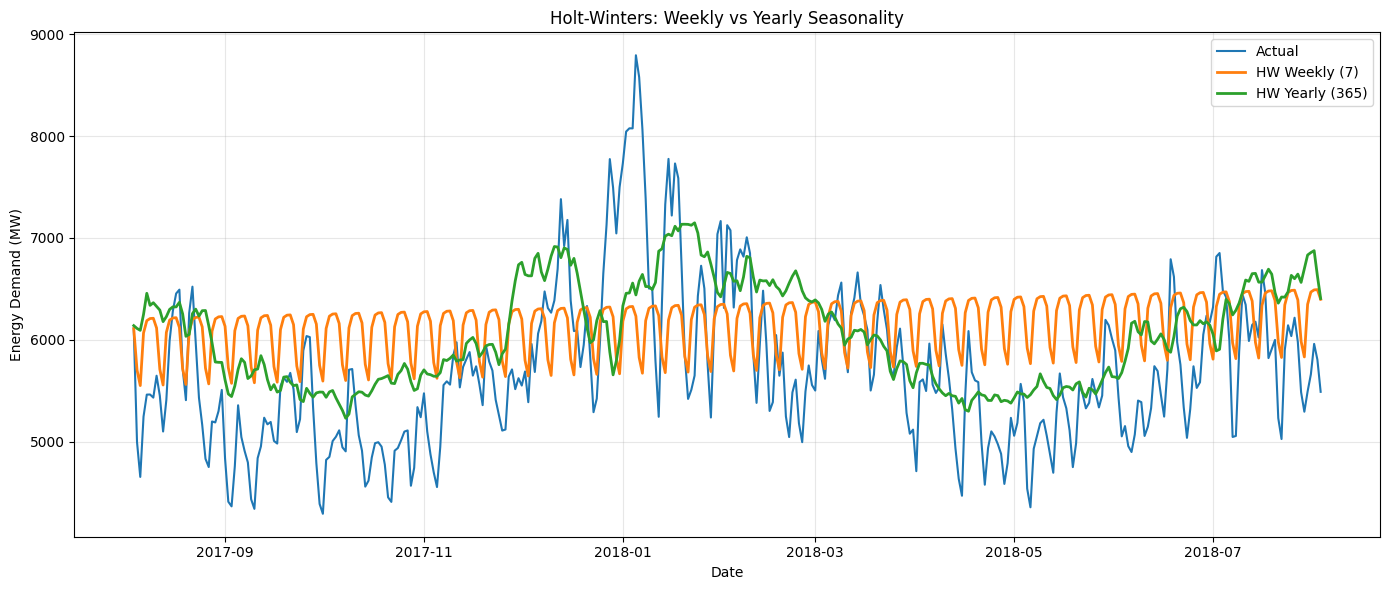

In [20]:
# ── 8.2 Compare Holt-Winters seasonal period choices visually ─────────────
plt.figure(figsize=(14, 6))

plt.plot(actual.index, actual, label='Actual', linewidth=1.5)
plt.plot(hw_weekly_forecast.index, hw_weekly_forecast, label='HW Weekly (7)', linewidth=2)
plt.plot(hw_yearly_forecast.index, hw_yearly_forecast, label='HW Yearly (365)', linewidth=2)

plt.title('Holt-Winters: Weekly vs Yearly Seasonality')
plt.xlabel('Date')
plt.ylabel('Energy Demand (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The version with **`seasonal_periods = 365`** achieves lower forecast error than the version with **`seasonal_periods = 7`**. This suggests that **annual seasonality has a stronger impact on accuracy than weekly seasonality**.


---
## Section 9 – Model C: Long Short-Term Memory (LSTM) Network

### Architecture
We test a few simple LSTM architectures and compare their performance.

The following configurations are used:

```
1. LSTM(32), batch size = 32, learning rate = 0.001  
2. LSTM(64, 32), batch size = 32, learning rate = 0.001  
3. LSTM(64, 32), batch size = 16, learning rate = 0.0005  
```
Each model includes dropout (0.2) to reduce overfitting and a Dense(1) output layer.

The best model is selected based on the lowest validation loss.

---

### Preprocessing
LSTM requires:
1. **Normalization** to [0, 1] using MinMaxScaler
2. **Sequence creation**: sliding window of `look_back = 60` days to predict the next day


In [21]:
# ── 9.1  Normalize data ───────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled  = scaler.transform(test.values.reshape(-1, 1))

# Combine for sequence creation (we need look_back days of history before test)
all_scaled = np.concatenate([train_scaled, test_scaled], axis=0)

print(f"Train scaled shape : {train_scaled.shape}")
print(f"Test  scaled shape : {test_scaled.shape}")
print(f"All   scaled shape : {all_scaled.shape}")

Train scaled shape : (5604, 1)
Test  scaled shape : (365, 1)
All   scaled shape : (5969, 1)


In [22]:
# ── 9.2  Create sliding window sequences ─────────────
LOOK_BACK = 60   # use past 60 days to predict next day

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

train_end_idx = len(train_scaled)

# Training sequences: only training data
X_train, y_train = create_sequences(train_scaled, LOOK_BACK)

# Test sequences: use last 60 training days to predict first test day
X_test, y_test = create_sequences(all_scaled[train_end_idx - LOOK_BACK:], LOOK_BACK)

# Reshape for LSTM: [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")

X_train : (5544, 60, 1)  y_train : (5544,)
X_test  : (365, 60, 1)   y_test  : (365,)


In [23]:
# ── 9.3  Build LSTM model ─────────────────────────────
from tensorflow.keras.optimizers import Adam

def build_lstm(look_back, units, learning_rate):
    model = Sequential()
    
    if len(units) == 1:
        model.add(LSTM(units[0], input_shape=(look_back, 1)))
        model.add(Dropout(0.2))
    else:
        model.add(LSTM(units[0], return_sequences=True, input_shape=(look_back, 1)))
        model.add(Dropout(0.2))
        model.add(LSTM(units[1]))
        model.add(Dropout(0.2))
    
    model.add(Dense(1))
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    return model

### Training Approach

- The data is split into training and validation sets  
- Early stopping is used to prevent overfitting  
- Each model is trained using the same number of epochs  
- Performance is compared using validation loss

The model with the best validation performance is used for final evaluation.

In [25]:
# ── 9.4 Simple LSTM Hyperparameter Tuning and Training ─────────────

lstm_settings = [
    {
        "Model": "LSTM(32), batch=32, lr=0.001",
        "units": [32],
        "batch_size": 32,
        "learning_rate": 0.001
    },
    {
        "Model": "LSTM(64,32), batch=32, lr=0.001",
        "units": [64, 32],
        "batch_size": 32,
        "learning_rate": 0.001
    },
    {
        "Model": "LSTM(64,32), batch=16, lr=0.0005",
        "units": [64, 32],
        "batch_size": 16,
        "learning_rate": 0.0005
    }
]

tuning_results = []
histories = {}
models = {}

for setting in lstm_settings:
    print(f"\nTraining {setting['Model']}")
    
    model = build_lstm(
        LOOK_BACK,
        units=setting["units"],
        learning_rate=setting["learning_rate"]
    )
    
    # Create a new EarlyStopping object for each model
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=setting["batch_size"],
        validation_split=0.1,
        callbacks=[early_stop],
        shuffle=False,
        verbose=0
    )
    
    best_val_loss = min(history.history["val_loss"])
    
    tuning_results.append({
        "Model": setting["Model"],
        "Units": setting["units"],
        "Batch Size": setting["batch_size"],
        "Learning Rate": setting["learning_rate"],
        "Best Validation Loss": best_val_loss,
        "Epochs Trained": len(history.history["loss"])
    })
    
    histories[setting["Model"]] = history
    models[setting["Model"]] = model

tuning_results_df = pd.DataFrame(tuning_results)
display(tuning_results_df)

best_lstm_row = tuning_results_df.loc[tuning_results_df["Best Validation Loss"].idxmin()]
best_lstm_name = best_lstm_row["Model"]

lstm_model = models[best_lstm_name]
history = histories[best_lstm_name]

print(f"\nBest LSTM setting selected: {best_lstm_name}")


Training LSTM(32), batch=32, lr=0.001

Training LSTM(64,32), batch=32, lr=0.001

Training LSTM(64,32), batch=16, lr=0.0005


,Model,Units,Batch Size,Learning Rate,Best Validation Loss,Epochs Trained
0,"LSTM(32), batch=32, lr=0.001",[32],32,0.0010,0.003461,50
1,"LSTM(64,32), batch=32, lr=0.001","[64, 32]",32,0.0010,0.003423,33
2,"LSTM(64,32), batch=16, lr=0.0005","[64, 32]",16,0.0005,0.003304,40



Best LSTM setting selected: LSTM(64,32), batch=16, lr=0.0005


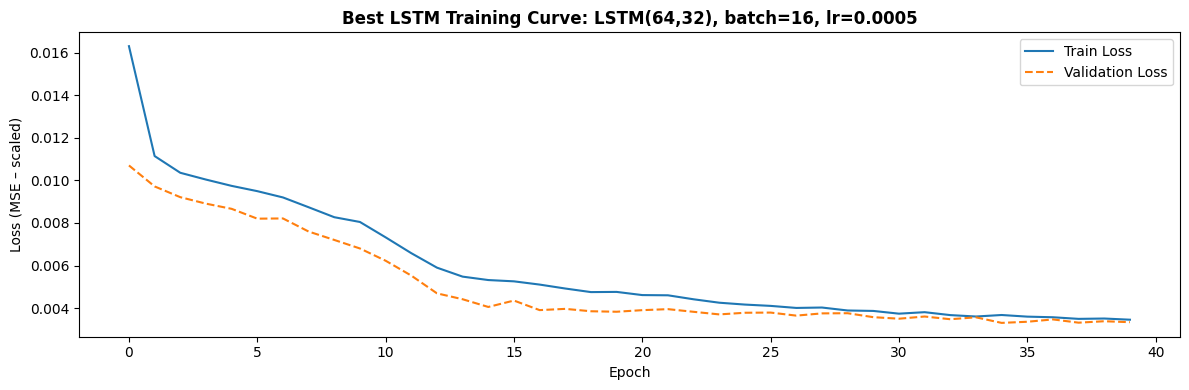

This graph shows how the model's error changes during training. The validation loss generally follows the training loss, suggesting stable learning.


In [26]:
# ── 9.5  Training curve ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
ax.set_title(f'Best LSTM Training Curve: {best_lstm_name}', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE – scaled)')
ax.legend()
plt.tight_layout()
plt.show()

print("This graph shows how the model's error changes during training. The validation loss generally follows the training loss, suggesting stable learning.")

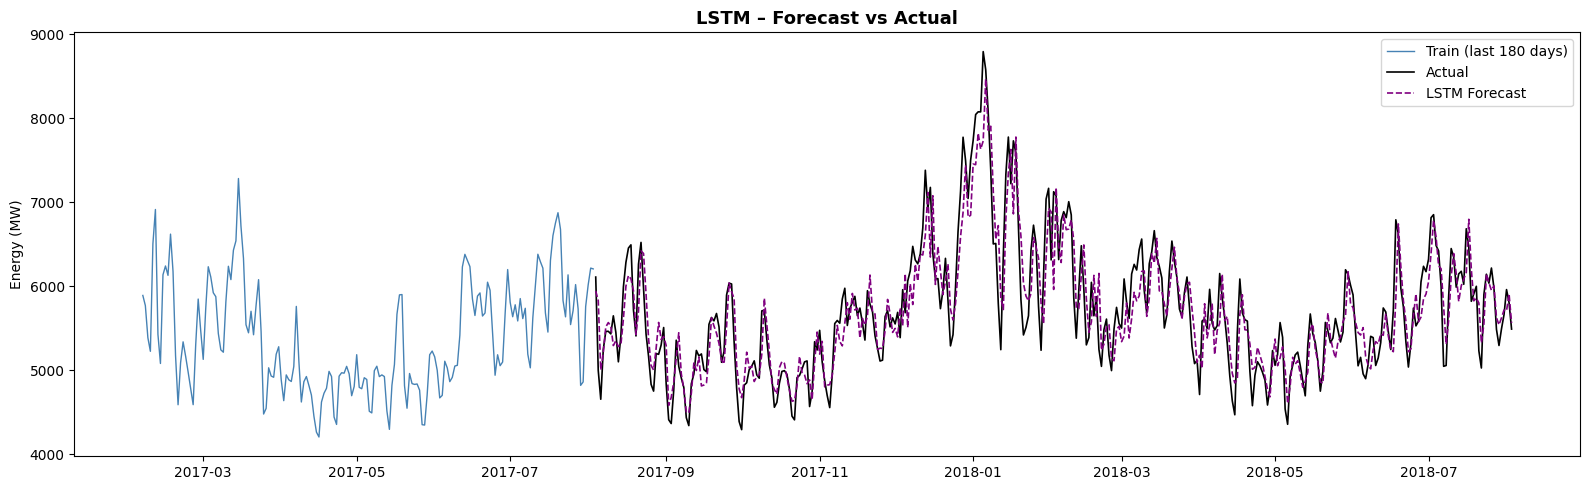

─────────────────────────────────────────────
  LSTM Performance
─────────────────────────────────────────────
  MAE  :     258.73 MW
  MSE  :  109440.97 MW²
  RMSE :     330.82 MW
  MAPE :       4.48 %


In [27]:
# ── 9.6  Forecast  ────────────────
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)
lstm_forecast    = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_forecast_s  = pd.Series(lstm_forecast, index=test.index[:len(lstm_forecast)])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train[-180:].index, train[-180:], color='steelblue', linewidth=1, label='Train (last 180 days)')
ax.plot(test.index, test,                 color='black',     linewidth=1.2, label='Actual')
ax.plot(lstm_forecast_s.index, lstm_forecast_s, color='purple', linewidth=1.2, linestyle='--', label='LSTM Forecast')
ax.set_title('LSTM – Forecast vs Actual', fontweight='bold', fontsize=13)
ax.set_ylabel('Energy (MW)')
ax.legend()
plt.tight_layout()
plt.show()

res_lstm = compute_metrics(test.values[:len(lstm_forecast)], lstm_forecast, 'LSTM')
results.append(res_lstm)

---
## Section 10 – Model Evaluation & Comparison

This section compares all models using MAE, MSE, RMSE, and MAPE. Lower values mean better forecasting performance.


In [28]:
# ── 10.1  Metrics comparison table ───────────────────
# Keep only the best version from each model family for final comparison
final_results = [best_arima_metrics, res_hw, res_lstm]

results_df = pd.DataFrame(final_results).set_index('Model')
results_df = results_df.round(2)

print("=== Model Performance Comparison ===")
print(results_df.to_string())
print()

best_rmse = results_df['RMSE'].idxmin()
best_mape = results_df['MAPE'].idxmin()
print(f"Best RMSE : {best_rmse} ({results_df.loc[best_rmse,'RMSE']:.2f} MW)")
print(f"Best MAPE : {best_mape} ({results_df.loc[best_mape,'MAPE']:.2f}%)")

=== Model Performance Comparison ===
                        MAE        MSE    RMSE   MAPE
Model                                                
Auto-ARIMA(4, 1, 1)  604.32  593406.55  770.33  10.68
Holt-Winters         591.22  531750.64  729.21  10.71
LSTM                 258.73  109440.97  330.82   4.48

Best RMSE : LSTM (330.82 MW)
Best MAPE : LSTM (4.48%)


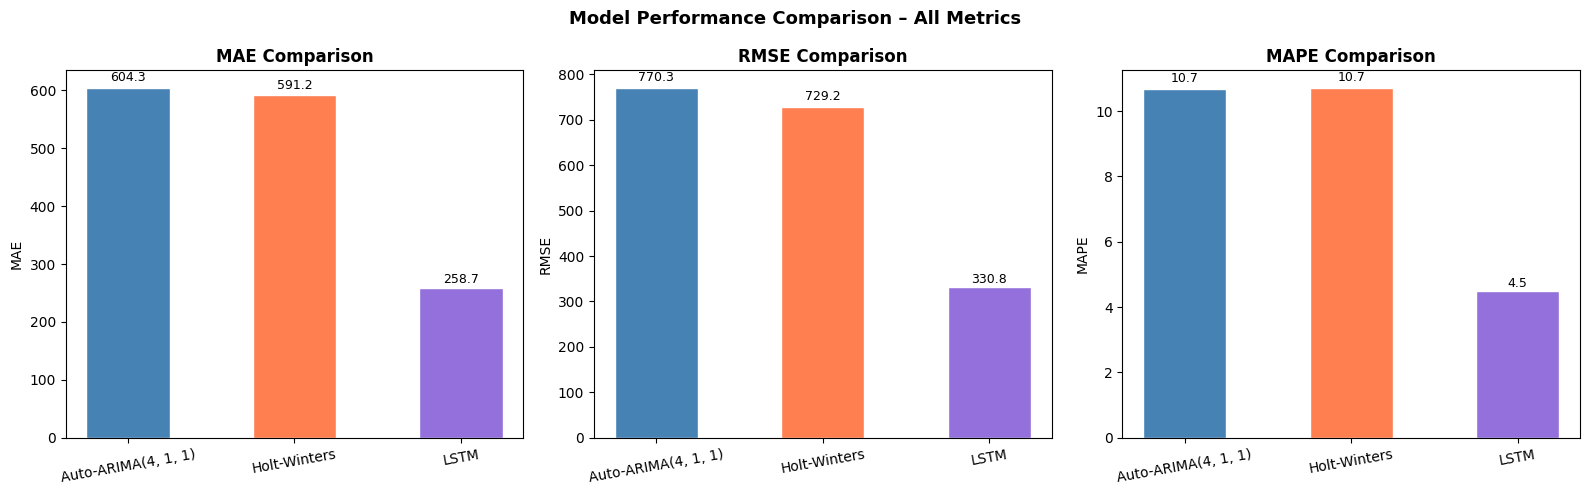

In [29]:
# ── 10.2  Bar chart comparison ────────────────────────
metrics_to_plot = ['MAE', 'RMSE', 'MAPE']
colors = ['steelblue', 'coral', 'mediumpurple']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(results_df.index, results_df[metric], color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(range(len(results_df.index)))
    ax.set_xticklabels(results_df.index, rotation=10)

plt.suptitle('Model Performance Comparison – All Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


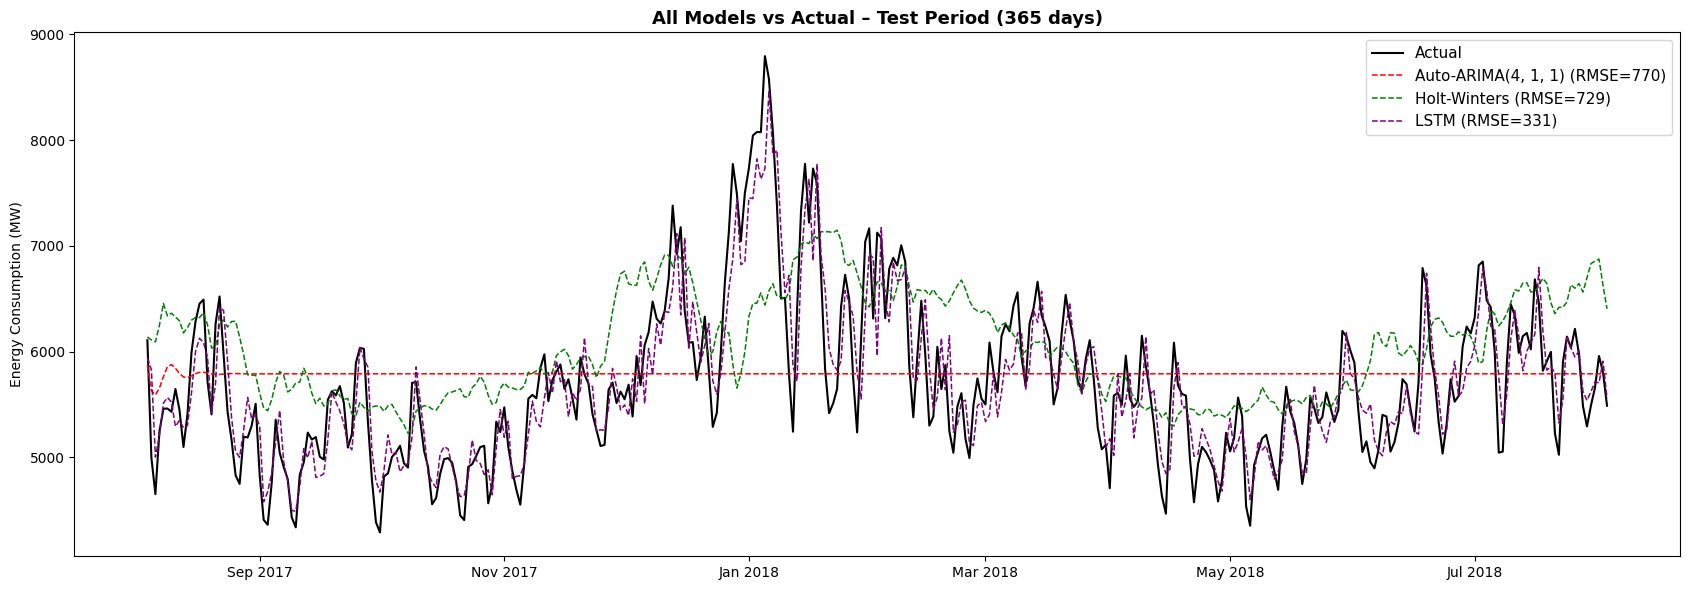

In [30]:
# ── 10.3  All forecasts on one plot ───────────────────
fig, ax = plt.subplots(figsize=(17, 6))
ax.plot(test.index, test, color='black', linewidth=1.5, label='Actual')
ax.plot(
    best_arima_forecast.index,
    best_arima_forecast,
    color='red',
    linewidth=1.1,
    linestyle='--',
    label=f"{best_arima_name} (RMSE={best_arima_metrics['RMSE']:.0f})"
)
ax.plot(
    hw_forecast.index,
    hw_forecast,
    color='green',
    linewidth=1.1,
    linestyle='--',
    label=f"Holt-Winters (RMSE={res_hw['RMSE']:.0f})"
)
ax.plot(
    lstm_forecast_s.index,
    lstm_forecast_s,
    color='purple',
    linewidth=1.1,
    linestyle='--',
    label=f"LSTM (RMSE={res_lstm['RMSE']:.0f})"
)
ax.set_title('All Models vs Actual – Test Period (365 days)', fontweight='bold', fontsize=13)
ax.set_ylabel('Energy Consumption (MW)')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

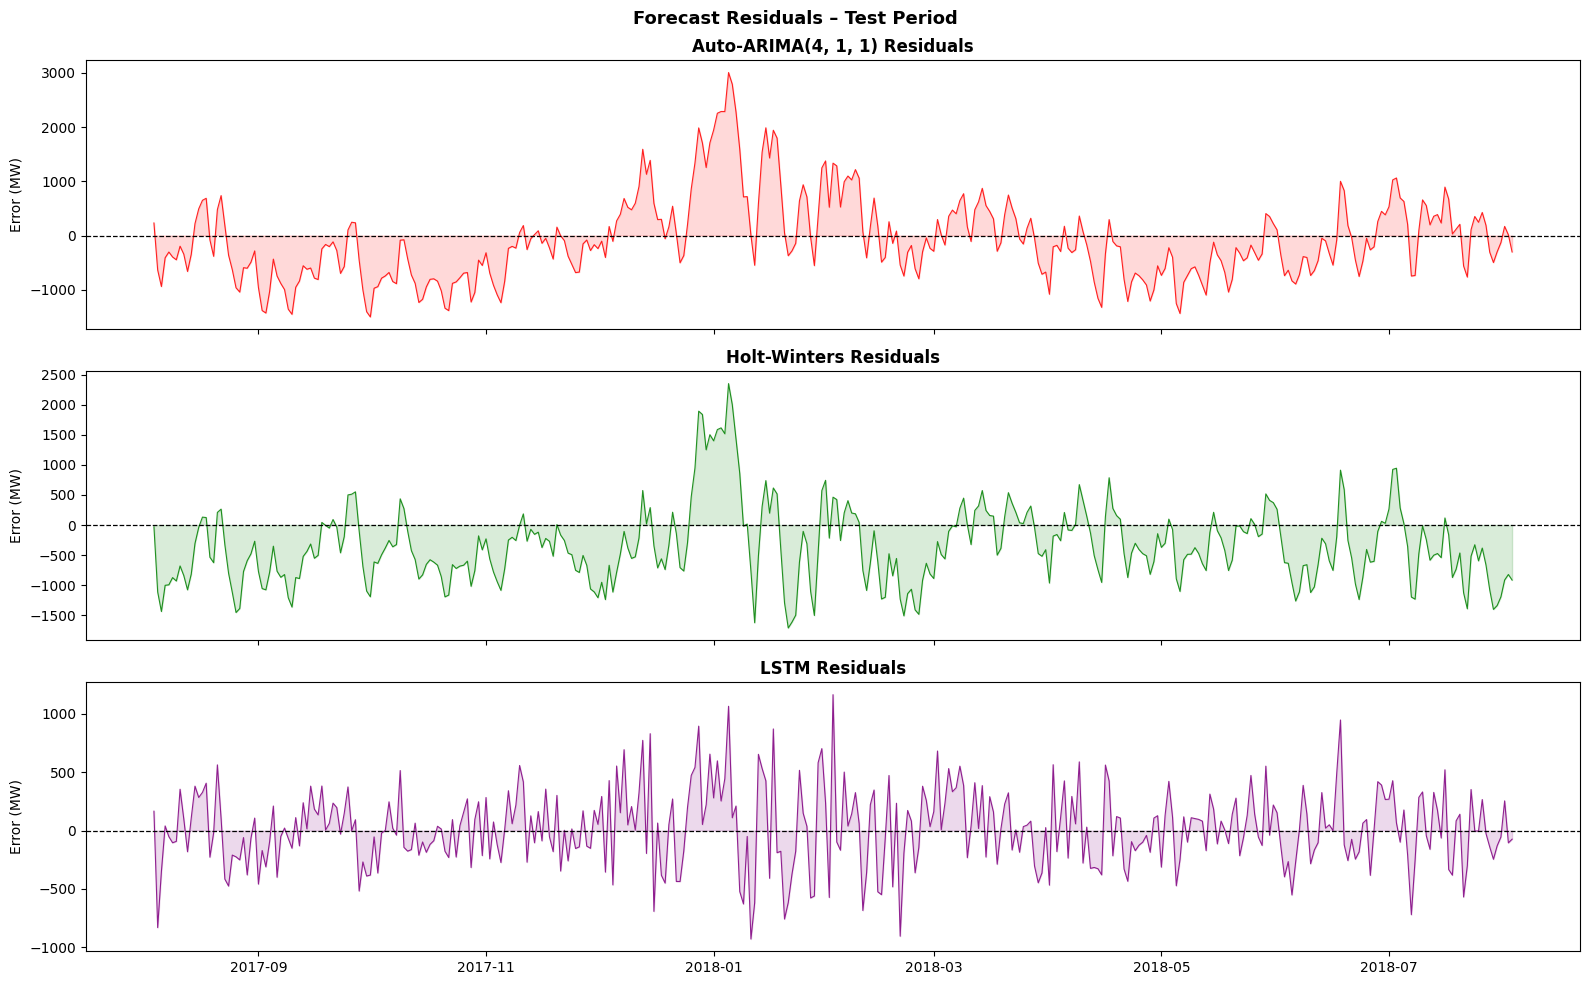

In [31]:
# ── 10.4  Residual (error) plots ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
pairs = [
    (test.values - best_arima_forecast.values, f'{best_arima_name} Residuals', 'red'),
    (test.values - hw_forecast.values, 'Holt-Winters Residuals', 'green'),
    (test.values[:len(lstm_forecast)] - lstm_forecast, 'LSTM Residuals', 'purple'),
]
for ax, (res, title, col) in zip(axes, pairs):
    ax.plot(test.index[:len(res)], res, color=col, linewidth=0.8, alpha=0.85)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Error (MW)')
    ax.fill_between(test.index[:len(res)], res, 0, alpha=0.15, color=col)

plt.suptitle('Forecast Residuals – Test Period', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 11 – Key Insights, Improvements, and Applications

### Key Insights:
- The PJMW daily energy demand series shows clear seasonal patterns, especially yearly seasonality.
- LSTM achieved the best forecasting accuracy based on MAE, RMSE, and MAPE.
- Holt-Winters slightly performed better than ARIMA because it captured seasonality more effectively.
- ARIMA was useful as a simple statistical baseline, but it could not fully capture the complex pattern of the data.

---

### Limitations:
- The original hourly data was converted to daily averages, so hourly patterns were lost.
- Only one variable (`PJMW_MW`) was used; weather and holidays were not included.
- Only one train/test split was used, so results may change with different evaluation settings.
- LSTM performed best, but it is harder to interpret than statistical models.

---

### Real-World Applications:
- Forecasting electricity demand for power system planning
- Helping utility companies with load balancing
- Supporting energy trading and scheduling
- Improving decisions for renewable energy integration


---

## Summary

Across three modeling approaches, the LSTM network achieved the lowest forecast error (MAPE 4.48%, RMSE 330.822 MW), cutting error roughly in half relative to the best classical baseline (Holt-Winters / Auto-ARIMA, ~10.7% MAPE). This points to a deep learning approach as the stronger fit for this series' seasonal structure, at the cost of reduced interpretability compared to the statistical models.


In [36]:
import pandas as pd
import os

os.makedirs("powerbi_export", exist_ok=True)

# 1. Actual vs. predicted, for every model, over the test period
df_predictions = pd.DataFrame({
    "Date": test.index,
    "Actual": test.values,
    "AutoARIMA": best_arima_forecast.values,
    "HoltWinters": hw_forecast.values,
    # LSTM has a shorter length due to the look-back window — pad the front with None
    "LSTM": [None] * (len(test) - len(lstm_forecast)) + list(lstm_forecast)
})
df_predictions.to_csv("powerbi_export/predictions.csv", index=False)

# 2. Model comparison metrics (already computed in your final comparison cell)
df_metrics = results_df.reset_index()  # the "=== Model Performance Comparison ===" table
df_metrics.columns = ["Model", "MAE", "MSE", "RMSE", "MAPE"]
df_metrics.to_csv("powerbi_export/metrics.csv", index=False)

# 3. Full historical series, for the trend/context chart
df_full = df.reset_index()
df_full.columns = ["Date", "Demand"]
df_full.to_csv("powerbi_export/full_history.csv", index=False)

# 4. Residuals, long format (Date, Model, Residual) — for the deep-dive page
residuals_long = pd.concat([
    pd.DataFrame({"Date": test.index[:len(best_arima_forecast)], "Model": "AutoARIMA",
                  "Residual": test.values[:len(best_arima_forecast)] - best_arima_forecast.values}),
    pd.DataFrame({"Date": test.index[:len(hw_forecast)], "Model": "HoltWinters",
                  "Residual": test.values[:len(hw_forecast)] - hw_forecast.values}),
    pd.DataFrame({"Date": test.index[-len(lstm_forecast):], "Model": "LSTM",
                  "Residual": test.values[-len(lstm_forecast):] - lstm_forecast}),
])
residuals_long.to_csv("powerbi_export/residuals.csv", index=False)

print("Exported 4 files to ./powerbi_export/")

Exported 4 files to ./powerbi_export/


In [35]:
print("df:", type(df), df.shape, df.values.shape)
print("test:", type(test), test.shape, test.values.shape)
print("best_arima_forecast:", type(best_arima_forecast), best_arima_forecast.shape)
print("hw_forecast:", type(hw_forecast), hw_forecast.shape)

df: <class 'pandas.DataFrame'> (5969, 1) (5969, 1)
test: <class 'pandas.Series'> (365,) (365,)
best_arima_forecast: <class 'pandas.Series'> (365,)
hw_forecast: <class 'pandas.Series'> (365,)
